Training samples: 3415
Training samples: 854


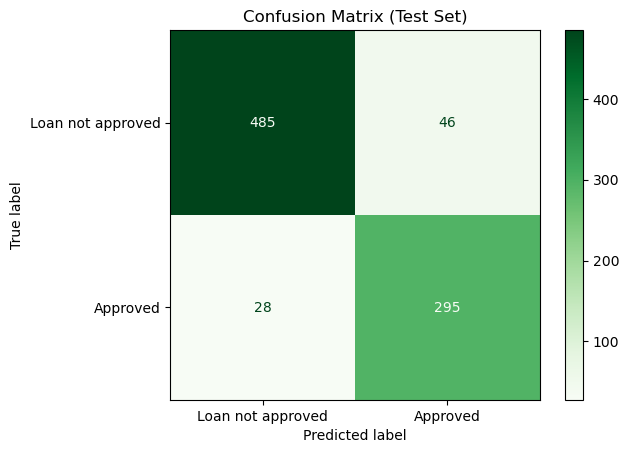


==== Test set Performance =====

Classification Report:

              precision    recall  f1-score   support

    Approved       0.95      0.91      0.93       531
    Rejected       0.87      0.91      0.89       323

    accuracy                           0.91       854
   macro avg       0.91      0.91      0.91       854
weighted avg       0.92      0.91      0.91       854

Top 10 customers most likely to get loan:
     customer_id  probability_approved
815         1728              0.998606
413         2811              0.998567
1            111              0.998516
340           30              0.998109
762          986              0.997992
123          966              0.997979
110         2693              0.997929
827         1752              0.997662
629         1122              0.997656
454          273              0.997577

Bottom 10 customers least likely to get loan:
     customer_id  probability_approved
753         1331              0.000017
56          2225   

In [41]:
#Assignment 4
#Question 1 : Predict loan approval on loan_approval_dataset.csv (in Github repo)
# (a) Use Logistic Regression
# (b) Then try using Naive Bayes
# (c) Perform encoding and scaling as appropriate
# (d) Display confusion matrix and customized classification matrix and customized classification report
# (e) Compare the results and check which one has a better accuracy
 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay
import pandas as pd

from sklearn.preprocessing import LabelEncoder,StandardScaler

#1. read dataset

df = pd.read_csv("loan_approval_dataset.csv")
df.dropna()
x=df.drop(["loan_status","loan_id"],axis=1)
y=df["loan_status"]

le = LabelEncoder()
x['education'] = le.fit_transform(df['education'])
x['self_employed'] = le.fit_transform(df['self_employed'])
x
cols_to_scale = ['no_of_dependents', 'loan_amount','income_annum','loan_amount','loan_term','cibil_score','residential_assets_value','commercial_assets_value','luxury_assets_value','bank_asset_value']

scaler = StandardScaler()
x[cols_to_scale] = scaler.fit_transform(x[cols_to_scale])

#Logistic Regression

x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.2,random_state=101,stratify=y
)
print(f"Training samples: {len(x_train)}")
print(f"Training samples: {len(x_test)}")

#Train full model (all feaqtures)
model = LogisticRegression(max_iter = 500)
model.fit(x_train,y_train)

#5.Evaluation on TEST set
y_pred = model.predict(x_test)
y_pred_lr=y_pred

cm = confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm,display_labels=["Loan not approved","Approved"]).plot(cmap="Greens")
plt.title("Confusion Matrix (Test Set)")
plt.show()

print("\n==== Test set Performance =====")
print("\nClassification Report:\n")
print(classification_report(y_test,y_pred))

# Get predicted probabilities for test set
y_probs = model.predict_proba(x_test)[:, 1]   # probability of loan_status = 1 (approved)

# Attach probabilities to customer IDs
results = pd.DataFrame({
    "customer_id": x_test.index,   # assuming index is customer_id
    "probability_approved": y_probs
})

# Top 10 most likely to get loan
top10 = results.sort_values("probability_approved", ascending=False).head(10)

# Bottom 10 least likely to get loan
bottom10 = results.sort_values("probability_approved", ascending=True).head(10)

print("Top 10 customers most likely to get loan:")
print(top10)

print("\nBottom 10 customers least likely to get loan:")
print(bottom10)






 Test Accuracy: 0.9274

Classification Report:
              precision    recall  f1-score   support

    Approved       0.96      0.92      0.94       531
    Rejected       0.88      0.93      0.91       323

    accuracy                           0.93       854
   macro avg       0.92      0.93      0.92       854
weighted avg       0.93      0.93      0.93       854

                   precision    recall  f1-score   support

Loan not approved       0.96      0.92      0.94       531
    Loan approved       0.88      0.93      0.91       323

         accuracy                           0.93       854
        macro avg       0.92      0.93      0.92       854
     weighted avg       0.93      0.93      0.93       854



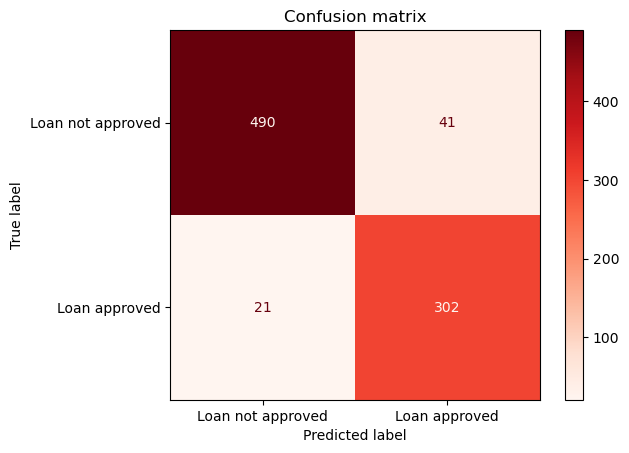

In [43]:
#NaiveBayes - loan approval

#3.Train naive Bayes on training data
model = GaussianNB()#Function which we use for naive baye's if we have many numeric data
model.fit(x_train,y_train)

#4.Evaluate on test set
y_pred = model.predict(x_test)
y_pred_nb = y_pred
accuracy = accuracy_score(y_test,y_pred)

print(f"\n Test Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test,y_pred))
report = classification_report(y_test,y_pred,target_names=['Loan not approved','Loan approved'])
print(report)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Loan not approved", "Loan approved"])
disp.plot(cmap="Reds")   # <-- valid colormap
plt.title("Confusion matrix")
plt.show()



In [46]:
diff_mask = y_pred_lr != y_pred_nb

# Extract those records
diff_records = x_test[diff_mask].copy()
diff_records['LR_pred'] = y_pred_lr[diff_mask]
diff_records['NB_pred'] = y_pred_nb[diff_mask]
diff_records['Actual'] = y_test[diff_mask]

print(diff_records)

      no_of_dependents  education  self_employed  income_annum  loan_amount  \
3990         -0.883825          1              1     -1.232535    -1.142790   
3076         -0.294102          0              1     -1.232535    -1.253381   
3163          0.295621          1              1      1.724873     1.279160   
2313         -0.883825          0              1      1.297296     1.832116   
1833         -0.883825          0              0      0.940982     1.345514   
3028         -0.883825          1              1     -1.054378    -1.209144   
2250         -0.294102          0              1      0.691562     0.427607   
3333         -1.473548          1              0      1.439822     1.245982   
3643          0.885344          1              1      0.691562     1.279160   
296           1.475067          1              1      1.261665     1.522460   
3364         -0.883825          0              1      0.050196     0.129010   
4001          1.475067          1              0    

In [ ]:
# # Assignment 4 (File in GitHub)
# Question 1: Predict loan approval on loan_approval_dataset.csv file (in GitHub repo).
# (a) Use Logistic Regression
# (b) Then try using Naive Bayes
# (c) Perform encoding and scaling as appropriate
# (d) Display confusion matrix and customized classification report
# (e) Compare the results and check which one has a better accuracy
# (f) For Logistic regression
# Show the top 10 customers most likely to get loan
# Show the bottom 10 customers least likely to get loan
# (g) Find records where predictions differ between LR nd NB and display those records - Analyze why the predictions differ

# Question 2: Create a dataset with 95% class 0 and 5% class 1
# Train logistic regression
# Evaluate performance


# Question 3: 
# (1) Create confusion matrix
# | Patient_ID | Actual_Result | Predicted_Result |
# | ---------- | ------------- | ---------------- |
# | P1         | Disease       | Disease          |
# | P2         | Disease       | Disease          |
# | P3         | Disease       | No Disease       |
# | P4         | Disease       | Disease          |
# | P5         | Disease       | No Disease       |
# | P6         | Disease       | Disease          |
# | P7         | No Disease    | No Disease       |
# | P8         | No Disease    | Disease          |
# | P9         | No Disease    | No Disease       |
# | P10        | No Disease    | No Disease       |
# | P11        | No Disease    | Disease          |
# | P12        | No Disease    | No Disease       |

# (2) Use the following data
# - What is the positive class?
# - Identify TP, TN, FP, FN.
# - Which error is more dangerous?

# | Passenger | Actual Status                | Scanner Result |
# | --------- | ---------------------------- | -------------- |
# | A         | Carrying prohibited item     | Alarm          |
# | B         | Not carrying prohibited item | Alarm          |
# | C         | Not carrying prohibited item | No Alarm       |
# | D         | Carrying prohibited item     | No Alarm       |
# | E         | Carrying prohibited item     | Alarm          |

# (3) Find accuracy without creating a confusion matrix
# | Email | Actual Spam | Predicted Spam |
# | ----- | ----------- | -------------- |
# | E1    | Yes         | Yes            |
# | E2    | No          | No             |
# | E3    | Yes         | No             |
# | E4    | No          | No             |
# | E5    | Yes         | Yes            |

# (4) A cancer screening system produced:
# 5 False Positives
# 2 False Negatives
# Which type of error is more dangerous in this application and why?

# (5) A bank's loan approval model has:
# 15 False Positives
# 3 False Negatives
# What does a False Positive mean here?
# What does a False Negative mean here?
# Which error would concern the bank more?